In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

from helpers.prepare_validation import prepare_validation
from helpers.load_satellite_data import load_satellite_data
from helpers.background_removal import background_removal
from helpers.symmetric_balances import group_balance
from helpers.aggregate_validation_triples import aggregate_validation_triples
from helpers.xgb_tuning import tune_xgb, fit_final
from helpers.feature_selection import select_features
from helpers.prediction import predict_raster
from helpers.export_indices import export_indices
from helpers.spatial_cv import (
    make_spatial_groups, spatial_cv_predict, regression_metrics,
    agreement_metrics, resolve_threshold,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error
)
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr
import seaborn as sns

In [ ]:
# ──────────────────────────────
# Set dataset + feature toggles here. Everything downstream branches on this.
# ──────────────────────────────
dataset   = "kenya"          # "kenya" or "oman"
buffer    = 500
EXCLUDE_VAL_IDS = [3, 5]  #3, 5  # validation point ids to drop from metrics (mis-sampled; decide later)
USE_GLOBAL_BACKGROUND = False   # False: local bkg within `buffer` m | True: whole-bkg center, perturb all
RESTRICT = True
satellite = f'fused_spot_s2_{dataset}'   # base fused file; SWIR sharpened on the fly if enabled

# --- on-the-fly feature toggles (fused tiff is never regenerated) ---
SHARPEN_SWIR    = False    # pan-sharpen SWIR B11/B12 to 1.5 m using SPOT NIR

# --- pixel-to-point footprint ---
# 1 = single pixel under each sample; 3 = 3x3 median (absorbs GPS / co-reg
# error at 1.5 m). Applied to bands BEFORE indices, and mirrored on inference.
WINDOW = 1

# --- training loss ---
# 'reg:squarederror' (L2) or 'reg:pseudohubererror' (robust; resists the
# heavy-tailed balance extremes). Huber auto-tunes its huber_slope (delta).
XGB_OBJECTIVE = "reg:pseudohubererror"

# --- elevated vs depleted agreement (direction, not magnitude) ---
# The study's claim is that predicted enrichment/depletion is REAL, not that
# magnitudes match. Threshold the balance into depleted (<thr) / elevated (>thr):
#   0.0        -> neutral point after background removal (>0 enriched, <0 depleted)
#   "antimode" -> GMM 2-population split learned from the training balance
# Applied to true & predicted; AUC additionally ranks the continuous prediction.
AGREEMENT_THRESHOLD = 0.0

USE_EMBEDDINGS  = False    # True -> add embedding bands as model features
EMB_INTERPOLATE = True     # True bilinear (smooth 1.5 m) | False nearest (hard 10 m)

CV_STRATEGY = "site"       # "site" leave-site-out | "block" KMeans spatial blocks
CV_N_BLOCKS = 5            # number of blocks when CV_STRATEGY == "block"
CV_MAX_FOLDS = None        # None -> leave-one-group-out | int -> GroupKFold(n)

# --- auto marker/background detection from the compositional dendrogram ---
AUTO_GROUPS       = True              # True -> derive markers & natural_bgk from dendrogram clusters
if dataset == "oman":
    ACTIVE_SITES        = ["S4","S7","S10"]
    GROUP_EXCLUDE_SITES = ["S11","S12"]
    GROUP_TYPE_PREFIX   = "CORRAL"
elif dataset == "kenya":  # kenya
    ACTIVE_SITES        = ["E2","E4","E7","E9"]   # pick your enclosure sites
    GROUP_EXCLUDE_SITES = []
    GROUP_TYPE_PREFIX   = "COR"   # matches both CORAL and CORRAL
PB_POPULATION_SPLIT = True           # detect background vs enriched populations in PB1 (GMM antimode)

CONFIG = {
    "kenya": {
        "natural_bgk": ['Ca', 'Cu', 'Zr', 'Ni', 'Rb', 'Si', 'Ti', 'Mg', 'Al', 'Fe'],
        "markers":     ['P', 'Zn', 'K', 'Mn', 'Sr'], 
        "has_validation": False,
        "mask_path": f'./output/{dataset}/baresoil_mask_{dataset}.tif',
        "embeddings_path": f'./data/satellite/embeddings_{dataset}.tif',
        "fillna_type": 'None',
    },
    "oman": {
        "natural_bgk": ['Si', 'Al', 'Fe', 'Ti', 'Mg'], #Auto
        "markers":     ['Cl','K'], # active:'Cl','K' || abandoned:'P','Sr', 'Zn', 'Mn'
         
        "has_validation": True,
        "mask_path": f'./output/{dataset}/baresoil_mask_{dataset}.tif',
        "embeddings_path": f'./data/satellite/embeddings_{dataset}.tif',
        "fillna_type": None,
    },
}
cfg = CONFIG[dataset]
natural_bgk = cfg["natural_bgk"]
markers     = cfg["markers"]
embeddings_path = cfg["embeddings_path"] if USE_EMBEDDINGS else None

# Per-region results folder — folder name = dataset, so exported tables and
# figures are self-labelling (output/oman/... vs output/kenya/...).
OUT_DIR = f'./output/{dataset}'
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Dataset: {dataset}  |  satellite: {satellite}")
print(f"SHARPEN_SWIR={SHARPEN_SWIR}  |  WINDOW={WINDOW}  |  USE_EMBEDDINGS={USE_EMBEDDINGS}")
print(f"Objective={XGB_OBJECTIVE}  |  CV_STRATEGY={CV_STRATEGY}  |  agree_thr={AGREEMENT_THRESHOLD}")
print(f"Has validation set: {cfg['has_validation']}  |  results -> {OUT_DIR}")

Dataset: kenya  |  satellite: fused_spot_s2_kenya
SHARPEN_SWIR=False  |  WINDOW=1  |  USE_EMBEDDINGS=False
Objective=reg:pseudohubererror  |  CV_STRATEGY=site  |  agree_thr=0.0
Has validation set: False  |  results -> ./output/kenya


In [3]:
# Load training data
gdf = gpd.read_file(f"./data/geospatial/{dataset}_processed_closed.geojson") #active 
if cfg["fillna_type"]:
    gdf['Type'] = gdf['Type'].fillna(cfg["fillna_type"])

# Detect markers vs natural background from the compositional dendrogram
if AUTO_GROUPS:
    from helpers.dendro_groups import compositional_groups
    _grp = compositional_groups(
        f"./data/geospatial/{dataset}_processed_closed.geojson",
        include_sites=ACTIVE_SITES, exclude_sites=GROUP_EXCLUDE_SITES,
        type_prefix=GROUP_TYPE_PREFIX,
        exclude_parts=('Res',),
        save_path=f'{OUT_DIR}/{dataset}_auto_groups.png',
    )
    markers     = _grp['markers']
    natural_bgk = _grp['natural_bgk']
    print(f"AUTO (n={_grp['n_samples']})  markers: {markers}")
    print(f"AUTO          natural_bgk: {natural_bgk}")
    if PB_POPULATION_SPLIT:
        from helpers.pb_populations import population_split
        _pb = population_split(_grp['top_balance'],
                               save_path=f'{OUT_DIR}/{dataset}_pb1_population.png', label='PB1')
        if _pb['bimodal']:
            print(f"  PB1 BIMODAL: antimode={_pb['threshold']:.3f} "
                  f"(background={_pb['n_low']}, enriched={_pb['n_high']})")
        else:
            print("  PB1 unimodal (single population)")
else:
    markers     = cfg["markers"]
    natural_bgk = cfg["natural_bgk"]

# Optional validation set
df_val = None
if cfg["has_validation"]:
    gdf_val = gpd.read_file("./data/geospatial/validation_processed_closed.geojson")
    # gdf_val = aggregate_validation_triples(gdf_val)
    gdf_val['Serial'] = gdf_val['Serial'].astype(str)
    gdf, gdf_val_bg, shared_elems = prepare_validation(gdf, gdf_val, restrict_training=RESTRICT)

# Background removal
gdf_removed_bgk = background_removal(gdf, buffer_distance=buffer, use_global_background=USE_GLOBAL_BACKGROUND)

if cfg["has_validation"]:
    gdf_val_removed_bgk = background_removal(gdf_val_bg, buffer_distance=buffer, use_global_background=USE_GLOBAL_BACKGROUND)
    gdf_val_removed_bgk = gdf_val_removed_bgk.loc[
        gdf_val_removed_bgk.index.intersection(gdf_val_bg['Serial'])
    ]
    df_val = gdf_val_removed_bgk.copy()

AUTO (n=56)  markers: ['Mg', 'P', 'K', 'Ca', 'Mn', 'Zn', 'Rb', 'Sr', 'Zr']
AUTO          natural_bgk: ['Al', 'Si', 'Ti', 'Fe', 'Y', 'Ba']
  PB1 BIMODAL: antimode=-1.095 (background=43, enriched=13)
✅ Background removal complete for 20 sites.


In [4]:
df = load_satellite_data(
    satellite_type=satellite, df_closed=gdf_removed_bgk,
    sharpen_swir=SHARPEN_SWIR,
    use_embeddings=USE_EMBEDDINGS,
    embeddings_path=embeddings_path,
    emb_interpolate=EMB_INTERPOLATE,
    window=WINDOW,
)
df.head(2)

Loading raster: ./data/satellite/fused_spot_s2_kenya.tif
  aggregated 23 multi-sample pixels
  added NDVI, SAVI
  added BSI, NDMI, Clay_Index
  added NDWI, Calcite_Index
  output: 1603 rows x 37 cols (16 elements + 14 bands + 7 indices)
✅ Satellite data integration complete


,Mg,Al,Si,P,K,Ca,Ti,Mn,Fe,Zn,...,S2_B8A_nir08,S2_B11_swir16,S2_B12_swir22,NDVI,SAVI,BSI,NDMI,Clay_Index,NDWI,Calcite_Index
Serial,,,,,,,,,,,,,,,,,,,,,
1,0.053379,0.048412,0.048347,0.142755,0.078327,0.068097,0.054814,0.052232,0.054433,0.059655,...,0.294070,0.412200,0.403100,0.126301,0.092481,0.206036,-0.211040,0.977923,-0.205210,0.011162
10,0.068888,0.059536,0.060452,0.053924,0.064399,0.058069,0.066212,0.061015,0.061347,0.060917,...,0.357408,0.413578,0.406775,0.121186,0.097807,0.146413,-0.117703,0.983551,-0.204946,0.008293


In [5]:
df['balance'] = group_balance(df, markers, natural_bgk)
if df_val is not None:
    df_val['balance'] = group_balance(df_val, markers, natural_bgk)
df.head(2)

✅ Completed balance comparing between marker-elements and natural-background.


,Mg,Al,Si,P,K,Ca,Ti,Mn,Fe,Zn,...,S2_B11_swir16,S2_B12_swir22,NDVI,SAVI,BSI,NDMI,Clay_Index,NDWI,Calcite_Index,balance
Serial,,,,,,,,,,,,,,,,,,,,,
1,0.053379,0.048412,0.048347,0.142755,0.078327,0.068097,0.054814,0.052232,0.054433,0.059655,...,0.412200,0.403100,0.126301,0.092481,0.206036,-0.211040,0.977923,-0.205210,0.011162,0.492595
10,0.068888,0.059536,0.060452,0.053924,0.064399,0.058069,0.066212,0.061015,0.061347,0.060917,...,0.413578,0.406775,0.121186,0.097807,0.146413,-0.117703,0.983551,-0.204946,0.008293,0.093957


In [6]:
# Map site label + coordinates onto the per-pixel frame (Serial-indexed),
# used to build spatial CV groups (leave-site-out / spatial blocks).
_meta = gdf.set_index('Serial')
df['Type'] = _meta.loc[df.index, 'Type'].values
df['Site'] = _meta.loc[df.index, 'Site'].values
df['_x']   = _meta.loc[df.index].geometry.x.values
df['_y']   = _meta.loc[df.index].geometry.y.values

# 'Emb_' picks up the embedding bands appended when USE_EMBEDDINGS is True.
sat_keywords   = ('Band_', 'Drag_', 'S2_', 'SPOT_', 'Maxar_', 'Emb_')
index_keywords = ('NDVI', 'SAVI', 'BSI', 'NDMI', 'NDWI', 'MSAVI',
                  'Clay', 'Calcite', 'Iron', 'EVI', 'NBR')
feature_cols = [c for c in df.columns
                if c.startswith(sat_keywords)
                or any(c.startswith(k) for k in index_keywords)]

X      = df[feature_cols].values
y      = df['balance'].values
strata = df['Type'].values

# Spatial CV groups: one group per site, or KMeans blocks on coordinates.
if CV_STRATEGY == "site":
    groups_all, group_labels = make_spatial_groups(
        sites=df['Site'].values, strategy="site")
else:
    groups_all, group_labels = make_spatial_groups(
        coords=df[['_x', '_y']].values, strategy="block", n_blocks=CV_N_BLOCKS)

n_emb = sum(c.startswith('Emb_') for c in feature_cols)
print(f"Features: {len(feature_cols)} ({n_emb} embeddings)  |  samples: {len(y)}")
print(f"CV groups ({CV_STRATEGY}): {len(np.unique(groups_all))}")

Features: 21 (0 embeddings)  |  samples: 1603
CV groups (site): 20


In [7]:
from collections import Counter

# Stratified split. Singleton Type classes (e.g. a lone 'INSIDE' sample) can't
# be stratified, so they are placed in TRAIN and the rest is stratify-split.
# This surfaces at 1.5 m because each sample gets its own pixel (no aggregation
# collapse), unlike on coarser grids.
# NOTE: this random split is kept only for the legacy "internal 20% test" and
# is spatially leaky; the honest estimate is the spatial-CV cell below.
strata = np.asarray(strata)
counts = Counter(strata)
rare_mask = np.array([counts[t] < 2 for t in strata])
if rare_mask.any():
    rare_types = sorted(set(strata[rare_mask]))
    print(f"[strata] singleton class(es) {rare_types} -> forced into TRAIN")

idx_all  = np.arange(len(y))
idx_rest = idx_all[~rare_mask]

tr, te = train_test_split(
    idx_rest, test_size=0.2, random_state=42, stratify=strata[~rare_mask],
)
idx_train = np.concatenate([tr, idx_all[rare_mask]])
idx_test  = te

X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]
groups_train    = groups_all[idx_train]   # site/block ids aligned to X_train
print(f"[split] train={len(idx_train)}  test={len(idx_test)}")

[split] train=1282  test=321


In [8]:
print("=== Optuna round 1 (full feature set, group-aware CV) ===")
# Pass groups so hyperparameters are selected on held-out SITES, not leaky
# random folds. n_splits caps leave-site-out to a GroupKFold for speed.
# objective=XGB_OBJECTIVE -> robust Huber fit when selected (huber_slope tuned).
best_params, best_iter, cv_r2 = tune_xgb(
    X_train, y_train, groups=groups_train, n_trials=20, n_splits=5,
    objective=XGB_OBJECTIVE)
print(f"Best group-CV R² = {cv_r2:.3f}  |  n_estimators = {best_iter}")
if 'huber_slope' in best_params:
    print(f"  tuned huber_slope (delta) = {best_params['huber_slope']:.3f}")

model_full = fit_final(X_train, y_train, best_params, best_iter,
                       objective=XGB_OBJECTIVE)

=== Optuna round 1 (full feature set, group-aware CV) ===
  Trial 0: R² = 0.120 (best: 0.120)
Best group-CV R² = 0.130  |  n_estimators = 12
  tuned huber_slope (delta) = 4.027


In [9]:
# Permutation importances (report only). No feature reduction: round-2
# retuning on reduced features did not beat round 1, so we keep all features.
kept_feats, importances = select_features(
    model_full, X_test, y_test, feature_cols, keep_frac=0.8,
)
print("\nAll feature importances:")
print(importances.round(4).to_string())

Permutation importance: 19 / 21 features have positive contribution
Keeping top 16 (keep_frac=0.8)
SPOT_green        0.1199
SPOT_red          0.0492
S2_B8A_nir08      0.0370
Clay_Index        0.0360
NDMI              0.0294
SPOT_nir          0.0218
NDWI              0.0171
SPOT_blue         0.0162
S2_B11_swir16     0.0157
S2_B12_swir22     0.0153
S2_B8_nir         0.0130
S2_B2_blue        0.0108
BSI               0.0093
NDVI              0.0089
S2_B7_rededge3    0.0078
dtype: float64

All feature importances:
SPOT_green        0.1199
SPOT_red          0.0492
S2_B8A_nir08      0.0370
Clay_Index        0.0360
NDMI              0.0294
SPOT_nir          0.0218
NDWI              0.0171
SPOT_blue         0.0162
S2_B11_swir16     0.0157
S2_B12_swir22     0.0153
S2_B8_nir         0.0130
S2_B2_blue        0.0108
BSI               0.0093
NDVI              0.0089
S2_B7_rededge3    0.0078
S2_B3_green       0.0071
Calcite_Index     0.0029
S2_B6_rededge2    0.0021
S2_B5_rededge1    0.0003
S2_B4_red 

In [10]:
model_eval = fit_final(X_train, y_train, best_params, best_iter,
                       objective=XGB_OBJECTIVE)

def regression_metrics_full(y, yhat):
    return dict(
        R2=r2_score(y, yhat),
        RMSE=np.sqrt(mean_squared_error(y, yhat)),
        MAE=mean_absolute_error(y, yhat),
        MAPE=mean_absolute_percentage_error(y, yhat),
        Pearson=np.corrcoef(y, yhat)[0, 1],
        Spearman=spearmanr(y, yhat).correlation,
    )

ridge = Ridge(alpha=1.0, random_state=42).fit(X_train, y_train)
print("\nInternal 20% test (spatially leaky — compare against spatial CV below):")
print(f"  Ridge   : {regression_metrics_full(y_test, ridge.predict(X_test))}")
print(f"  XGBoost : {regression_metrics_full(y_test, model_eval.predict(X_test))}")

X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])
model = fit_final(X_all, y_all, best_params, best_iter, objective=XGB_OBJECTIVE)
print(f"\nFinal model refit on full data: {len(y_all)} samples")


Internal 20% test (spatially leaky — compare against spatial CV below):
  Ridge   : {'R2': 0.0324681353625933, 'RMSE': np.float64(0.333656516822738), 'MAE': 0.16073639207520196, 'MAPE': 5.0031493424376245, 'Pearson': np.float64(0.20945533891516263), 'Spearman': np.float64(0.14333821907470834)}
  XGBoost : {'R2': 0.10501403875136517, 'RMSE': np.float64(0.32090396617533534), 'MAE': 0.1432757668273889, 'MAPE': 3.2398233346529035, 'Pearson': np.float64(0.3300392746593464), 'Spearman': np.float64(0.4188683040188738)}

Final model refit on full data: 1603 samples


/Users/antonkout/miniforge3/envs/camp-geomatics/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.78317e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [11]:
# ── Spatial cross-validation: the honest generalization estimate ──────────
# Each fold trains on all sites but one (leave-site-out) or on a GroupKFold
# partition of spatial blocks, then predicts the held-out group. Out-of-fold
# predictions never see a pixel from their own site, so these numbers reflect
# transfer to unseen ground — expect them LOWER than the leaky 20% test.
oof_pred, fold_r2, cv_name = spatial_cv_predict(
    X, y, groups_all, best_params, best_iter, max_folds=CV_MAX_FOLDS,
    objective=XGB_OBJECTIVE,
)

valid = np.isfinite(oof_pred)
cv_metrics = regression_metrics(y[valid], oof_pred[valid])

print(f"Spatial CV ({cv_name}, {CV_STRATEGY}): "
      f"{len(np.unique(groups_all))} groups, n={valid.sum()}")
print(f"  loss: {XGB_OBJECTIVE}  |  window: {WINDOW}  |  "
      f"embeddings: {'ON' if USE_EMBEDDINGS else 'off'} ({n_emb} bands)  |  "
      f"features: {len(feature_cols)}")
for k, v in cv_metrics.items():
    print(f"  {k:9s}: {v:.3f}")
if fold_r2:
    print(f"  per-fold R²: mean={np.mean(fold_r2):.3f}  "
          f"std={np.std(fold_r2):.3f}  (min={np.min(fold_r2):.3f}, "
          f"max={np.max(fold_r2):.3f})")

# Keep a labelled record so successive runs (window 1 vs 3, embeddings off vs
# on, L2 vs Huber) can be compared in one place.
try:
    cv_log
except NameError:
    cv_log = []
cv_log.append({
    'dataset': dataset, 'cv': CV_STRATEGY, 'window': WINDOW,
    'loss': XGB_OBJECTIVE, 'embeddings': USE_EMBEDDINGS,
    'n_features': len(feature_cols),
    **{k: round(v, 3) for k, v in cv_metrics.items()},
})
pd.DataFrame(cv_log)

Spatial CV (LeaveOneGroupOut, site): 20 groups, n=1603
  loss: reg:pseudohubererror  |  window: 1  |  embeddings: off (0 bands)  |  features: 21
  R2       : 0.023
  RMSE     : 0.313
  MAE      : 0.157
  Pearson  : 0.226
  Spearman : 0.169
  per-fold R²: mean=-0.426  std=0.864  (min=-3.776, max=0.250)


,dataset,cv,window,loss,embeddings,n_features,R2,RMSE,MAE,Pearson,Spearman
0,kenya,site,1,reg:pseudohubererror,False,21,0.023,0.313,0.157,0.226,0.169


In [12]:
# ── Elevated vs depleted AGREEMENT on the spatial-CV out-of-fold predictions ─
# Direction-not-magnitude scoreboard: threshold true & predicted balance, then
# score the classification. AUC is threshold-free — it ranks the continuous
# prediction, i.e. "does the model order enriched samples above depleted ones?"
# Threshold is fixed from the TRAINING balance (never from the held-out data).
agree_thr = resolve_threshold(AGREEMENT_THRESHOLD, y)
oof_agree = agreement_metrics(y[valid], oof_pred[valid], threshold=agree_thr)

print(f"Spatial-CV agreement  (thr={agree_thr:.3f}, spec={AGREEMENT_THRESHOLD!r})")
print(f"  classes: elevated={oof_agree['n_elevated']}  "
      f"depleted={oof_agree['n_depleted']}")
for k in ['AUC', 'balanced_acc', 'MCC', 'kappa', 'F1', 'accuracy']:
    print(f"  {k:12s}: {oof_agree[k]:.3f}")
print(f"  confusion   TP={oof_agree['TP']}  FP={oof_agree['FP']}  "
      f"FN={oof_agree['FN']}  TN={oof_agree['TN']}")

# One combined table: regression (for reviewers) + agreement (the actual claim).
try:
    agree_log
except NameError:
    agree_log = []
agree_log.append({
    'eval': 'spatial_cv', 'dataset': dataset, 'window': WINDOW,
    'loss': XGB_OBJECTIVE, 'embeddings': USE_EMBEDDINGS, 'thr': round(agree_thr, 3),
    'R2': round(cv_metrics['R2'], 3), 'Spearman': round(cv_metrics['Spearman'], 3),
    'AUC': round(oof_agree['AUC'], 3), 'bal_acc': round(oof_agree['balanced_acc'], 3),
    'MCC': round(oof_agree['MCC'], 3),
})
pd.DataFrame(agree_log)

Spatial-CV agreement  (thr=0.000, spec=0.0)
  classes: elevated=1074  depleted=529
  AUC         : 0.591
  balanced_acc: 0.543
  MCC         : 0.117
  kappa       : 0.102
  F1          : 0.778
  accuracy    : 0.661
  confusion   TP=954  FP=424  FN=120  TN=105


,eval,dataset,window,loss,embeddings,thr,R2,Spearman,AUC,bal_acc,MCC
0,spatial_cv,kenya,1,reg:pseudohubererror,False,0.0,0.023,0.169,0.591,0.543,0.117


In [13]:
# Predict, keeping ONLY bare-soil pixels (mask=1). Same SWIR + embedding +
# window settings as training so the feature vectors match exactly.
# Continuous prediction raster is written into output/{dataset}/ alongside the
# metrics and figures, so each region's results live in one folder.
prediction_path = predict_raster(
    model=model, satellite=satellite, feature_cols=feature_cols,
    mask_path=cfg['mask_path'], mask_keep_value=1,
    sharpen_swir=SHARPEN_SWIR,
    use_embeddings=USE_EMBEDDINGS,
    embeddings_path=embeddings_path,
    emb_interpolate=EMB_INTERPOLATE,
    window=WINDOW,
    output_path=f"{OUT_DIR}/{dataset}_balance_prediction.tif"
)

Model expects 21 features
Raster: 14 bands, 1836x1928
  added NDVI, SAVI
  added BSI, NDMI, Clay_Index
  added NDWI, Calcite_Index
Feature matrix: (3539808, 21), expected 21
  predicted: 3,539,808 pixels (100.0%)
  mask applied: kept 2,001,898 / 3,539,808 (56.6%)
Saved → ./output/kenya/kenya_balance_prediction.tif


In [14]:
# Export the spectral indices as standalone maps: output/{dataset}/{dataset}_{index}.tif
# Same SWIR + window toggles as training/inference, so each raster is exactly
# the feature the model saw. Masked to bare soil like the prediction.
index_paths = export_indices(
    satellite=satellite, dataset=dataset,
    indices=('NDVI', 'BSI', 'NDWI', 'Clay', 'Calcite'),
    out_dir=OUT_DIR,
    mask_path=cfg['mask_path'], mask_keep_value=1,
    sharpen_swir=SHARPEN_SWIR,
    window=WINDOW,
)

Raster: 14 bands, 1836x1928
  added NDVI, SAVI
  added BSI, NDMI, Clay_Index
  added NDWI, Calcite_Index
  mask: keeping 2,001,898 / 3,539,808 (56.6%)
  NDVI     -> ./output/kenya/kenya_NDVI.tif  [0.000 .. 0.357]
  BSI      -> ./output/kenya/kenya_BSI.tif  [-0.136 .. 0.261]
  NDWI     -> ./output/kenya/kenya_NDWI.tif  [-0.363 .. 0.000]
  Clay     -> ./output/kenya/kenya_Clay.tif  [0.000 .. 1.102]
  Calcite  -> ./output/kenya/kenya_Calcite.tif  [-0.049 .. 0.089]


In [15]:
if cfg["has_validation"]:
    # External validation: sample predicted raster at validation points
    with rasterio.open(prediction_path) as src:
        pts = df_val.to_crs(src.crs)
        coords = [(p.x, p.y) for p in pts.geometry]
        sampled = np.array([v[0] for v in src.sample(coords)], dtype=np.float32)

    df_eval = pd.DataFrame({
        'true':      df_val['balance'].values,
        'predicted': sampled,
    })
    df_eval = df_eval.replace([np.inf, -np.inf], np.nan).dropna()
    df_eval['residual'] = df_eval['predicted'] - df_eval['true']
    if EXCLUDE_VAL_IDS:
        drop = [i for i in EXCLUDE_VAL_IDS if i in df_eval.index]
        if drop:
            print(f"  excluding validation ids {drop} from metrics (mis-sampled)")
            df_eval = df_eval.drop(index=drop)
    eval_label = 'External validation'
else:
    # Internal 20% test split
    y_pred_internal = model_eval.predict(X_test)
    df_eval = pd.DataFrame({
        'true':      y_test,
        'predicted': y_pred_internal,
        'residual':  y_pred_internal - y_test,
    }).reset_index(drop=True)
    eval_label = 'Internal 20% test'

print(f"{eval_label}: n = {len(df_eval)}")
df_eval.head()

Internal 20% test: n = 321


,true,predicted,residual
0,0.086391,-0.013439,-0.099830
1,-0.138459,0.062349,0.200808
2,0.016417,0.006400,-0.010016
3,1.707318,0.085707,-1.621612
4,-0.001613,0.123937,0.125551


saved figure -> ./output/kenya/kenya_internal_20%_test_pred_vs_true.png


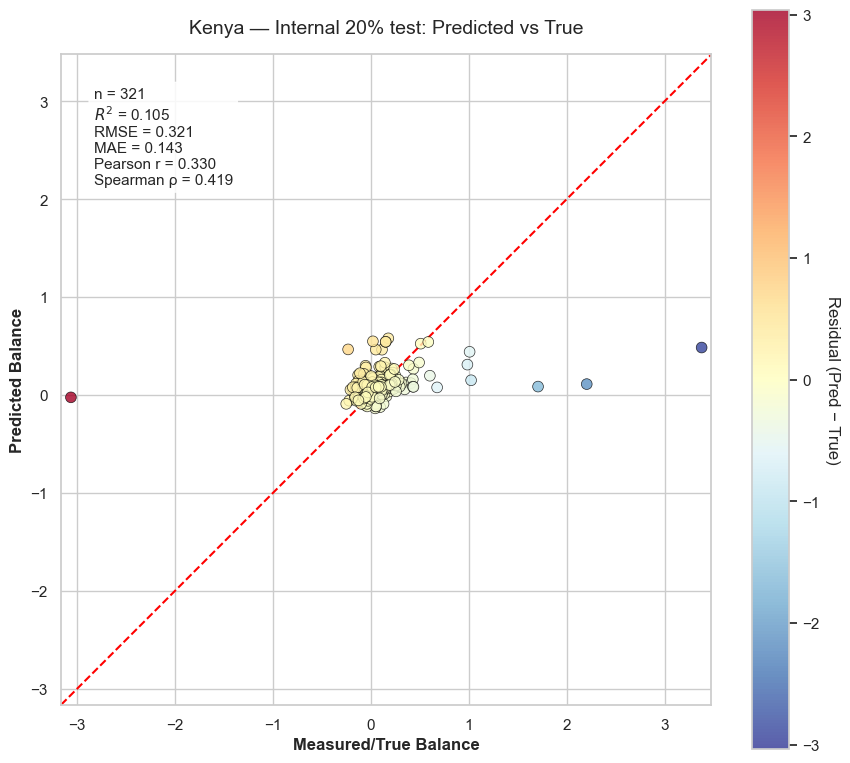

In [16]:
y_true    = df_eval['true'].values
y_pred    = df_eval['predicted'].values
residuals = df_eval['residual'].values

r2       = r2_score(y_true, y_pred)
rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
mae      = mean_absolute_error(y_true, y_pred)
pearson  = np.corrcoef(y_true, y_pred)[0, 1]
spearman = spearmanr(y_true, y_pred).correlation

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 8))

vmax = max(abs(residuals.min()), abs(residuals.max()))
sc = ax.scatter(y_true, y_pred, c=residuals, cmap='RdYlBu_r',
                vmin=-vmax, vmax=vmax,
                s=60, alpha=0.8, edgecolor='black', linewidth=0.5, zorder=3)

cbar = plt.colorbar(sc)
cbar.set_label('Residual (Pred − True)', rotation=270, labelpad=15)

# Point labels only for small validation sets
if len(df_eval) <= 80:
    for idx, row in df_eval.iterrows():
        ax.text(row['true'] + 0.015, row['predicted'] + 0.015,
                str(idx), fontsize=8, alpha=0.8, zorder=4)

lims = [min(y_true.min(), y_pred.min()) - 0.1,
        max(y_true.max(), y_pred.max()) + 0.1]
ax.plot(lims, lims, color='red', linestyle='--', lw=1.5,
        label='Ideal (1:1)', zorder=2)

stats_text = (f'n = {len(df_eval)}\n'
              f'$R^2$ = {r2:.3f}\n'
              f'RMSE = {rmse:.3f}\n'
              f'MAE = {mae:.3f}\n'
              f'Pearson r = {pearson:.3f}\n'
              f'Spearman ρ = {spearman:.3f}')
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

ax.set_xlabel('Measured/True Balance', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Balance', fontsize=12, fontweight='bold')
ax.set_title(f'{dataset.title()} — {eval_label}: Predicted vs True',
             fontsize=14, pad=15)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
plt.tight_layout()

_slug = eval_label.lower().replace(' ', '_')
_fig_path = f'{OUT_DIR}/{dataset}_{_slug}_pred_vs_true.png'
fig.savefig(_fig_path, dpi=200, bbox_inches='tight')
print(f"saved figure -> {_fig_path}")
plt.show()

Internal 20% test agreement  (thr=0.000, n=321)
  classes: elevated=203  depleted=118
  AUC         : 0.700
  balanced_acc: 0.627
  MCC         : 0.341
  kappa       : 0.290
  F1          : 0.804
  accuracy    : 0.710
  confusion   TP=191  FP=81  FN=12  TN=37
saved figure -> ./output/kenya/kenya_internal_20%_test_agreement.png


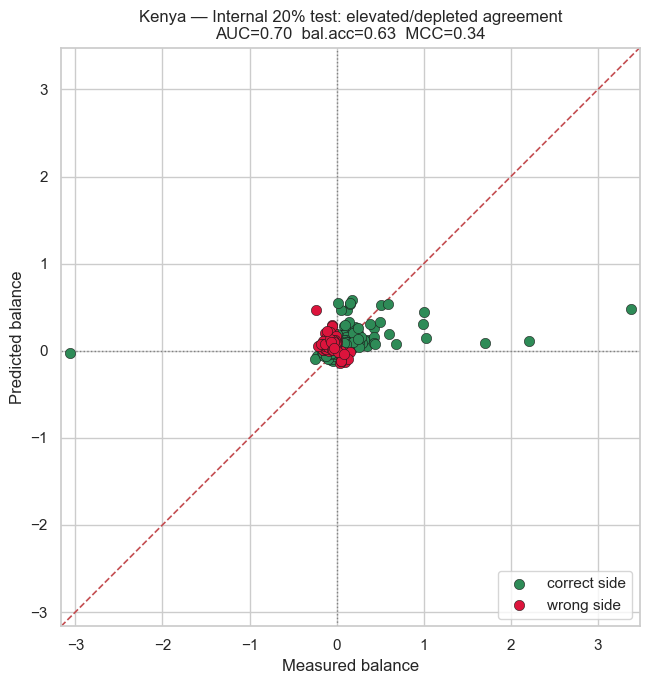

,eval,dataset,window,loss,embeddings,thr,R2,Spearman,AUC,bal_acc,MCC
0,spatial_cv,kenya,1,reg:pseudohubererror,False,0.0,0.023,0.169,0.591,0.543,0.117
1,Internal 20% test,kenya,1,reg:pseudohubererror,False,0.0,0.105,0.419,0.700,0.627,0.341


In [17]:
# ── Elevated vs depleted AGREEMENT on the evaluation set (external or internal)
# Same direction-not-magnitude scoreboard as the spatial-CV cell, on df_eval.
# The threshold is fixed from the TRAINING balance so "elevated" means the same
# thing in both regions (important for the Oman->Kenya method-transfer claim).
eval_thr   = resolve_threshold(AGREEMENT_THRESHOLD, y)
eval_agree = agreement_metrics(df_eval['true'].values,
                               df_eval['predicted'].values, threshold=eval_thr)

print(f"{eval_label} agreement  (thr={eval_thr:.3f}, n={len(df_eval)})")
print(f"  classes: elevated={eval_agree['n_elevated']}  "
      f"depleted={eval_agree['n_depleted']}")
for k in ['AUC', 'balanced_acc', 'MCC', 'kappa', 'F1', 'accuracy']:
    print(f"  {k:12s}: {eval_agree[k]:.3f}")
print(f"  confusion   TP={eval_agree['TP']}  FP={eval_agree['FP']}  "
      f"FN={eval_agree['FN']}  TN={eval_agree['TN']}")

# Confusion matrix on the predicted-vs-true scatter: colour by correct/incorrect
# side of the threshold, so the figure shows WHERE direction is right or wrong.
yt = df_eval['true'].values > eval_thr
yp = df_eval['predicted'].values > eval_thr
correct = yt == yp
fig, ax = plt.subplots(figsize=(7.5, 7))
ax.axhline(eval_thr, color='grey', ls=':', lw=1)
ax.axvline(eval_thr, color='grey', ls=':', lw=1)
ax.scatter(df_eval['true'][correct], df_eval['predicted'][correct],
           c='seagreen', s=55, edgecolor='k', lw=.4, label='correct side', zorder=3)
ax.scatter(df_eval['true'][~correct], df_eval['predicted'][~correct],
           c='crimson', s=55, edgecolor='k', lw=.4, label='wrong side', zorder=3)
lims = [min(df_eval['true'].min(), df_eval['predicted'].min()) - 0.1,
        max(df_eval['true'].max(), df_eval['predicted'].max()) + 0.1]
ax.plot(lims, lims, 'r--', lw=1.2, zorder=2)
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
ax.set_xlabel('Measured balance'); ax.set_ylabel('Predicted balance')
ax.set_title(f"{dataset.title()} — {eval_label}: elevated/depleted agreement\n"
             f"AUC={eval_agree['AUC']:.2f}  bal.acc={eval_agree['balanced_acc']:.2f}  "
             f"MCC={eval_agree['MCC']:.2f}")
ax.legend(loc='lower right'); plt.tight_layout()

_slug = eval_label.lower().replace(' ', '_')
_fig_path = f'{OUT_DIR}/{dataset}_{_slug}_agreement.png'
fig.savefig(_fig_path, dpi=200, bbox_inches='tight')
print(f"saved figure -> {_fig_path}")
plt.show()

try:
    agree_log
except NameError:
    agree_log = []
agree_log.append({
    'eval': eval_label, 'dataset': dataset, 'window': WINDOW,
    'loss': XGB_OBJECTIVE, 'embeddings': USE_EMBEDDINGS, 'thr': round(eval_thr, 3),
    'R2': round(r2, 3), 'Spearman': round(spearman, 3),
    'AUC': round(eval_agree['AUC'], 3), 'bal_acc': round(eval_agree['balanced_acc'], 3),
    'MCC': round(eval_agree['MCC'], 3),
})
pd.DataFrame(agree_log)

In [18]:
# ── Export metric tables to output/{dataset}/ ─────────────────────────────
# Folder name = dataset, so provenance (Oman vs Kenya) is explicit. Run the
# whole notebook first so cv_log (spatial-CV regression) and agree_log
# (regression + elevated/depleted agreement, per eval) are populated.
os.makedirs(OUT_DIR, exist_ok=True)

reg_df   = pd.DataFrame(cv_log)
agree_df = pd.DataFrame(agree_log)

reg_path   = f'{OUT_DIR}/{dataset}_metrics_regression.csv'
agree_path = f'{OUT_DIR}/{dataset}_metrics_agreement.csv'
reg_df.to_csv(reg_path, index=False)
agree_df.to_csv(agree_path, index=False)

print(f"saved: {reg_path}   ({len(reg_df)} rows)")
print(f"saved: {agree_path} ({len(agree_df)} rows)")
print(f"figures + tables in: {OUT_DIR}/")
agree_df

saved: ./output/kenya/kenya_metrics_regression.csv   (1 rows)
saved: ./output/kenya/kenya_metrics_agreement.csv (2 rows)
figures + tables in: ./output/kenya/


,eval,dataset,window,loss,embeddings,thr,R2,Spearman,AUC,bal_acc,MCC
0,spatial_cv,kenya,1,reg:pseudohubererror,False,0.0,0.023,0.169,0.591,0.543,0.117
1,Internal 20% test,kenya,1,reg:pseudohubererror,False,0.0,0.105,0.419,0.700,0.627,0.341
